# Predictive Maintenance_Machine Failure Classification

## 1. Import All Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.figsize'] = (11, 6)
sns.set_style('whitegrid')

print('All libraries imported successfully.')

All libraries imported successfully.



## 2. Load & Inspect Dataset

In [5]:
df = pd.read_csv('predictive_maintenance.csv')

print('Dataset Shape   :', df.shape)
print('Total Rows      :', df.shape[0])
print('Total Columns   :', df.shape[1])
print('\nAll Column Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')
print()
df.head(10)

Dataset Shape   : (10000, 10)
Total Rows      : 10000
Total Columns   : 10

All Column Names:
   1. UDI
   2. Product ID
   3. Type
   4. Air temperature [K]
   5. Process temperature [K]
   6. Rotational speed [rpm]
   7. Torque [Nm]
   8. Tool wear [min]
   9. Target
  10. Failure Type



,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure



## 3.Data Info, Types & Missing Values

In [80]:

print(df.dtypes)

print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(mv_df)
print('\nTotal missing cells:', missing.sum())

print('\n=== Descriptive Statistics (Numeric Columns) ===')
df.describe().round(3)

UDI                           int64
Product ID                   object
Type                         object
Air temperature [K]         float64
Process temperature [K]     float64
Rotational speed [rpm]        int64
Torque [Nm]                 float64
Tool wear [min]               int64
Target                        int64
Failure Type                 object
Torque_bin                 category
ToolWear_bin               category
dtype: object

=== Missing Values ===
                         Missing Count  Missing %
UDI                                  0        0.0
Product ID                           0        0.0
Type                                 0        0.0
Air temperature [K]                  0        0.0
Process temperature [K]              0        0.0
Rotational speed [rpm]               0        0.0
Torque [Nm]                          0        0.0
Tool wear [min]                      0        0.0
Target                               0        0.0
Failure Type                  

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.005,310.006,1538.776,39.987,107.951,0.034
std,2886.896,2.000,1.484,179.284,9.969,63.654,0.181
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000
25%,2500.750,298.300,308.800,1423.000,33.200,53.000,0.000
50%,5000.500,300.100,310.100,1503.000,40.100,108.000,0.000
75%,7500.250,301.500,311.100,1612.000,46.800,162.000,0.000
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000


## RQ1: What is the overall distribution of machine failures? How do failures spread across product quality types?
###  4.Target Variable Distribution (Failure vs No Failure)

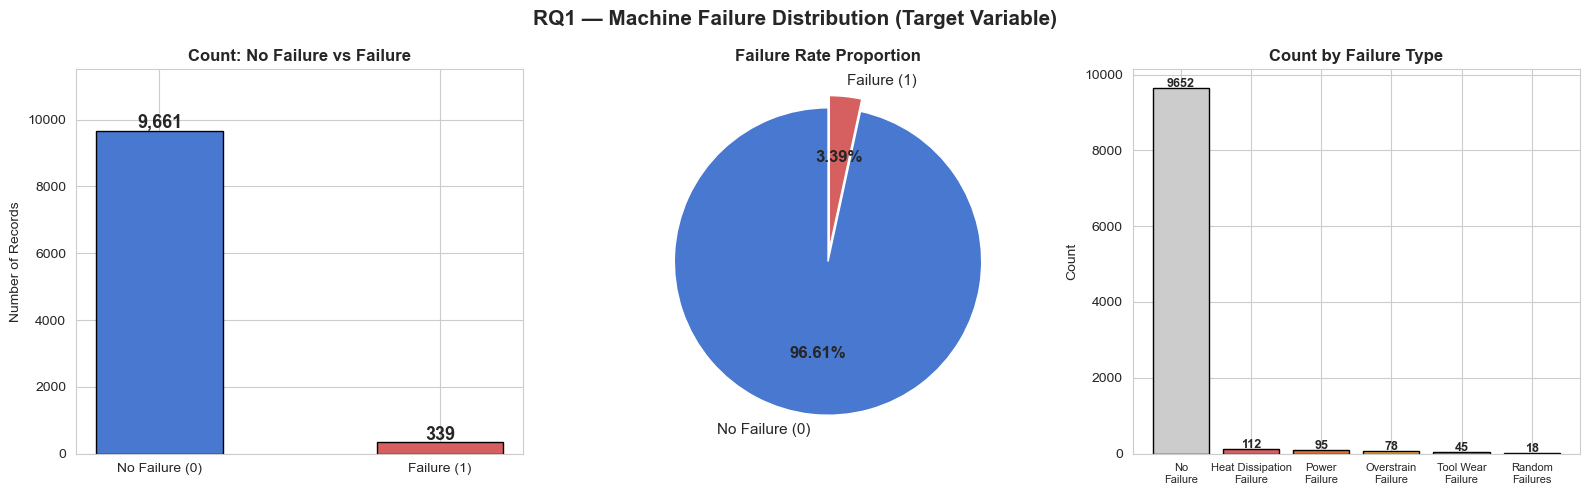

No Failure (0): 9,661  (96.61%)
Failure    (1): 339  (3.39%)
Total          : 10,000

Failure Type Breakdown:
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18


In [83]:
# RQ1 — Part A: Overall failure distribution
target_counts = df['Target'].value_counts().sort_index()
labels = ['No Failure (0)', 'Failure (1)']
colors = ['#4878CF', '#D65F5F']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RQ1 — Machine Failure Distribution (Target Variable)', fontsize=15, fontweight='bold')

# Bar chart
bars = axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', width=0.45)
axes[0].set_title('Count: No Failure vs Failure', fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_ylim(0, 11500)
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}', ha='center', fontsize=13, fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    target_counts.values, labels=labels,
    autopct='%1.2f%%', colors=colors,
    startangle=90, explode=(0, 0.08),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(12)
axes[1].set_title('Failure Rate Proportion', fontweight='bold')

# Failure Type breakdown
ft_counts = df['Failure Type'].value_counts()
ft_colors = ['#cccccc', '#D65F5F', '#E36E2E', '#E8A838', '#6ACC65', '#8172B2']
axes[2].bar(range(len(ft_counts)), ft_counts.values, color=ft_colors, edgecolor='black')
axes[2].set_xticks(range(len(ft_counts)))
axes[2].set_xticklabels(
    [l.replace(' Failure','\nFailure').replace('No Failure','No\nFailure') for l in ft_counts.index],
    fontsize=8
)
axes[2].set_title('Count by Failure Type', fontweight='bold')
axes[2].set_ylabel('Count')
for i, val in enumerate(ft_counts.values):
    axes[2].text(i, val + 30, str(val), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('fig_rq1a_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'No Failure (0): {target_counts[0]:,}  ({target_counts[0]/len(df)*100:.2f}%)')
print(f'Failure    (1): {target_counts[1]:,}  ({target_counts[1]/len(df)*100:.2f}%)')
print(f'Total          : {len(df):,}')
print('\nFailure Type Breakdown:')
print(df['Failure Type'].value_counts().to_string())

### 5. RQ1: Failure Distribution by Product Quality Type (L / M / H)

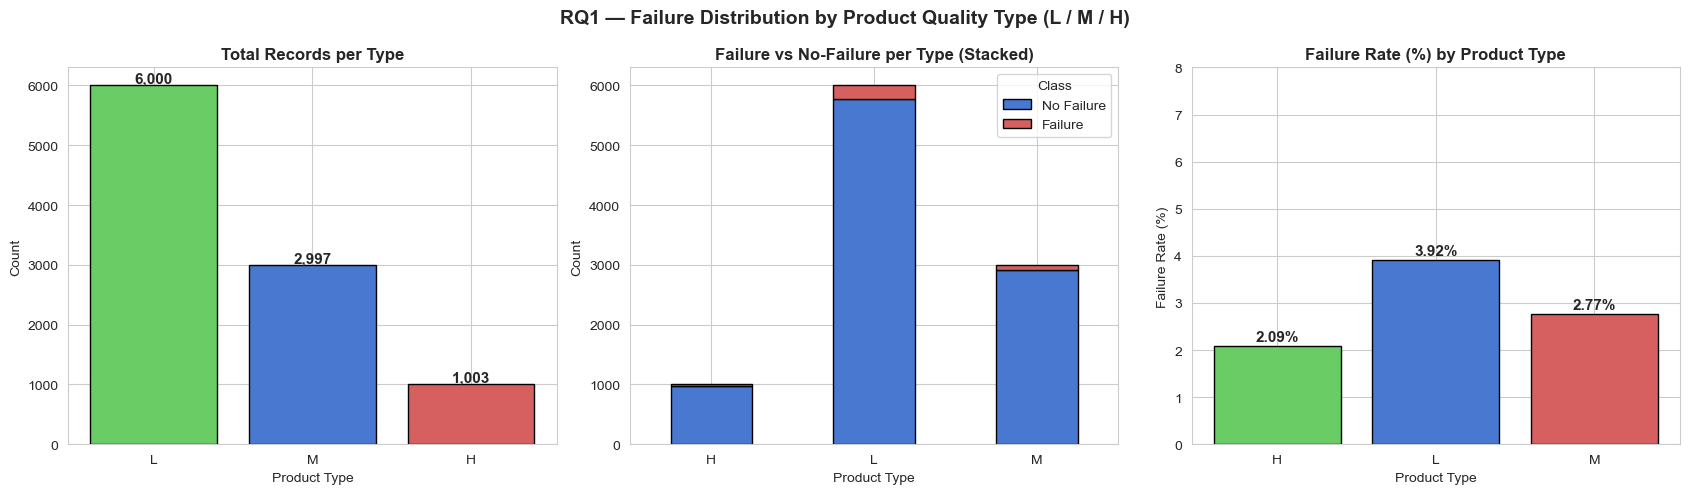

Table: Failure Counts by Product Type 
      No Failure  Failure  Total  Failure Rate %
Type                                            
H            982       21   1003            2.09
L           5765      235   6000            3.92
M           2914       83   2997            2.77


In [85]:
# RQ1 — Part B: Distribution across product quality types
type_counts  = df['Type'].value_counts()
type_fail    = pd.crosstab(df['Type'], df['Target'])
type_fail.columns = ['No Failure', 'Failure']
type_fail_rate = (df.groupby('Type')['Target'].mean() * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('RQ1 — Failure Distribution by Product Quality Type (L / M / H)',
             fontsize=14, fontweight='bold')

# Total count per type
type_colors = ['#6ACC65', '#4878CF', '#D65F5F']
bars = axes[0].bar(type_counts.index, type_counts.values, color=type_colors, edgecolor='black')
axes[0].set_title('Total Records per Type', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Product Type')
for bar, val in zip(bars, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

# Stacked bar
type_fail.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#4878CF', '#D65F5F'], edgecolor='black')
axes[1].set_title('Failure vs No-Failure per Type (Stacked)', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Product Type')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Class')

# Failure rate %
bars3 = axes[2].bar(type_fail_rate.index, type_fail_rate.values,
                    color=type_colors, edgecolor='black')
axes[2].set_title('Failure Rate (%) by Product Type', fontweight='bold')
axes[2].set_ylabel('Failure Rate (%)')
axes[2].set_xlabel('Product Type')
axes[2].set_ylim(0, 8)
for bar, val in zip(bars3, type_fail_rate.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('fig_rq1b_type_failure.png', dpi=150, bbox_inches='tight')
plt.show()

print('Table: Failure Counts by Product Type ')
summary = type_fail.copy()
summary['Total'] = summary.sum(axis=1)
summary['Failure Rate %'] = type_fail_rate
print(summary.to_string())


## RQ2: Which product quality type has the highest failure rate? How does each failure type differ across L/M/H?
### 6.Failure Type Analysis by Product Type

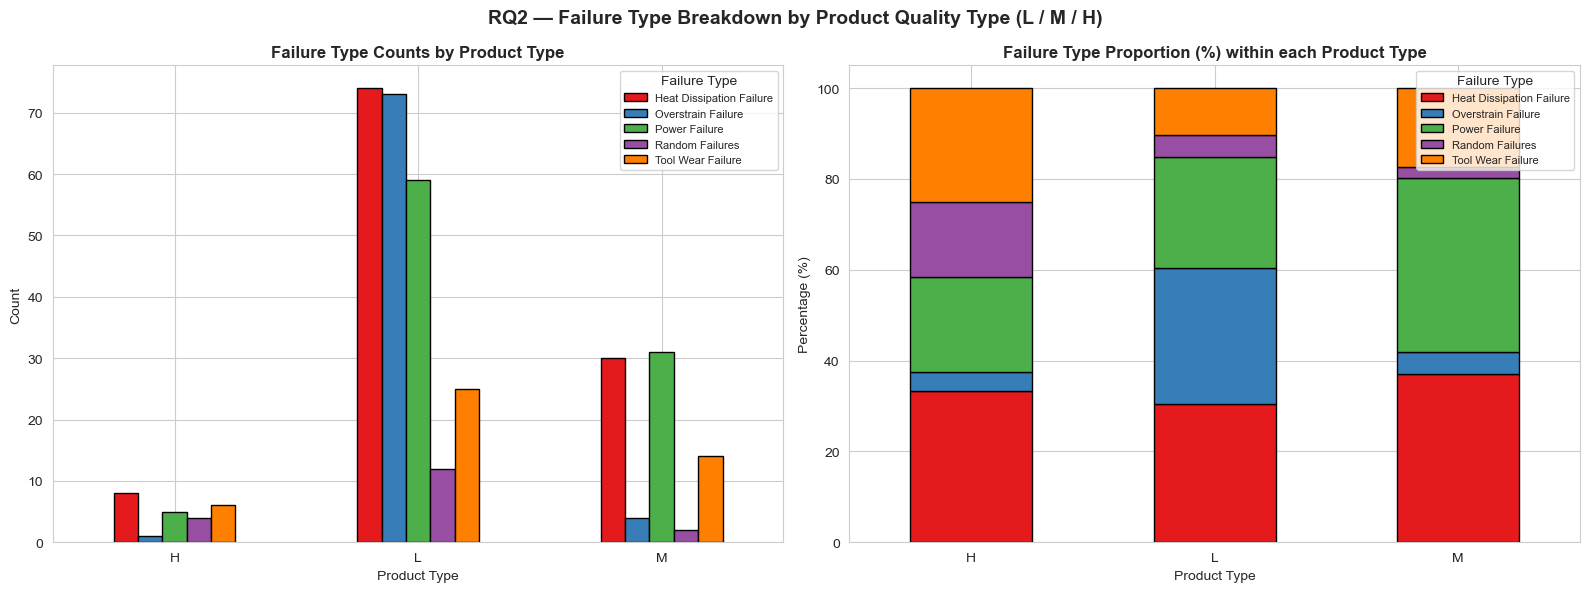

Table: Failure Type Counts by Product Quality Type
Failure Type  Heat Dissipation Failure  No Failure  Overstrain Failure  Power Failure  Random Failures  Tool Wear Failure
Type                                                                                                                     
H                                    8         979                   1              5                4                  6
L                                   74        5757                  73             59               12                 25
M                                   30        2916                   4             31                2                 14


In [88]:
# RQ2 — Failure type breakdown by product quality
ft_type = pd.crosstab(df['Type'], df['Failure Type'])
# drop No Failure for failure-only view
ft_type_fail = ft_type.drop(columns='No Failure', errors='ignore')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RQ2 — Failure Type Breakdown by Product Quality Type (L / M / H)',
             fontsize=14, fontweight='bold')

# Grouped bar — failure types by product type
ft_type_fail.plot(kind='bar', ax=axes[0],
                  color=sns.color_palette('Set1', len(ft_type_fail.columns)),
                  edgecolor='black')
axes[0].set_title('Failure Type Counts by Product Type', fontweight='bold')
axes[0].set_xlabel('Product Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Failure Type', fontsize=8, loc='upper right')

# Stacked proportion
ft_type_fail_norm = ft_type_fail.div(ft_type_fail.sum(axis=1), axis=0) * 100
ft_type_fail_norm.plot(kind='bar', stacked=True, ax=axes[1],
                       color=sns.color_palette('Set1', len(ft_type_fail.columns)),
                       edgecolor='black')
axes[1].set_title('Failure Type Proportion (%) within each Product Type', fontweight='bold')
axes[1].set_xlabel('Product Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Failure Type', fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('fig_rq2_failure_type_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

print('Table: Failure Type Counts by Product Quality Type')
print(ft_type.to_string())

## RQ3 — Which sensor features are most correlated with machine failure?
### 7. Correlation Heatmap

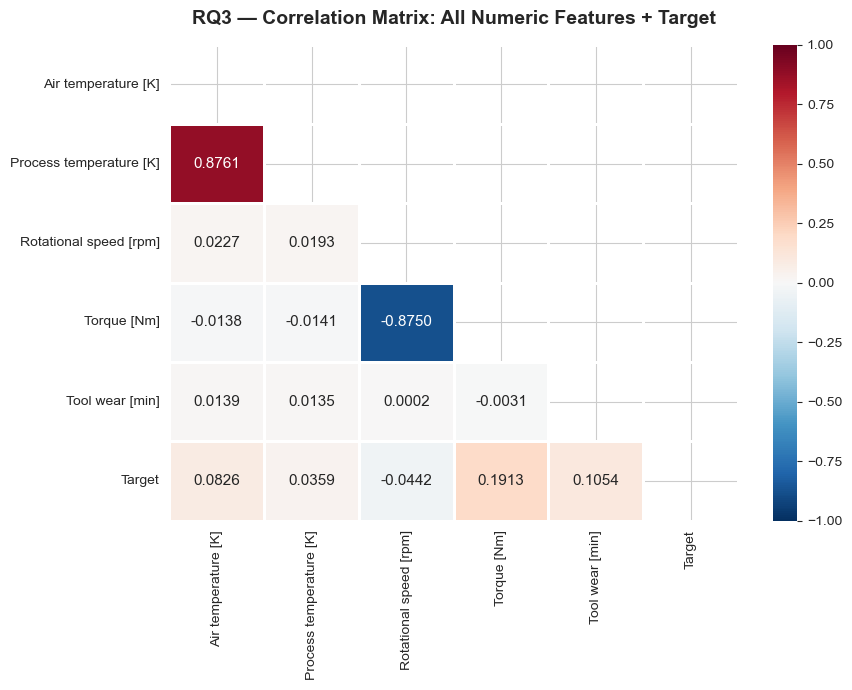

=== Correlation with Target (sorted by magnitude) ===
  Torque [Nm]                    +0.1913   Positive (+)
  Tool wear [min]                +0.1054   Positive (+)
  Air temperature [K]            +0.0826   Positive (+)
  Rotational speed [rpm]         -0.0442   Negative (-)
  Process temperature [K]        +0.0359   Positive (+)


In [90]:
# RQ3 — Correlation matrix (numeric features + Target)
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]',
            'Tool wear [min]', 'Target']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.4f',
    cmap='RdBu_r', center=0, linewidths=0.8,
    annot_kws={'size': 11}, vmin=-1, vmax=1, ax=ax
)
ax.set_title('RQ3 — Correlation Matrix: All Numeric Features + Target',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_rq3a_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Correlation with Target (sorted by magnitude) ===')
tc = corr['Target'].drop('Target').sort_values(key=abs, ascending=False)
for feat, val in tc.items():
    direction = 'Positive (+)' if val > 0 else 'Negative (-)'
    print(f'  {feat:<30} {val:+.4f}   {direction}')

### 8. RQ3: Feature Distributions by Failure Class (Histograms)

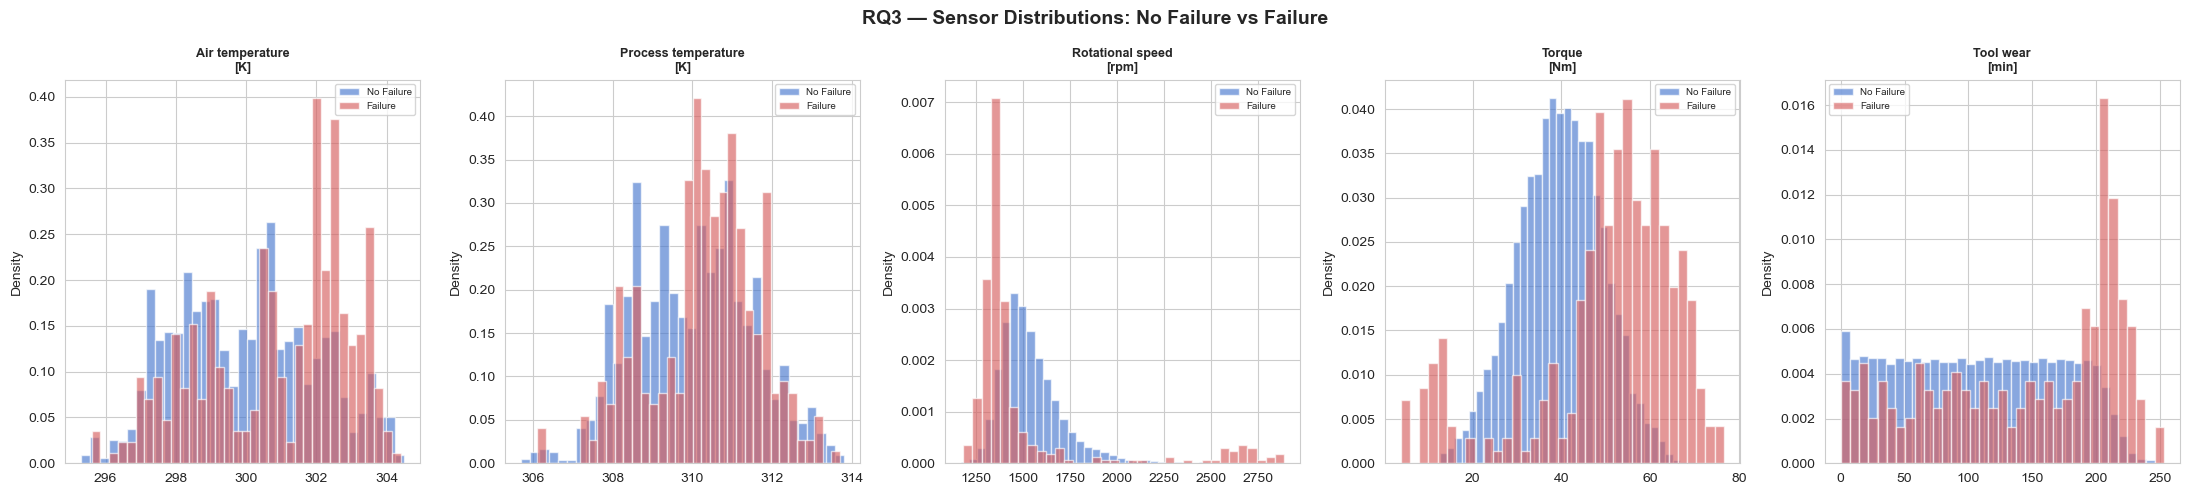

In [95]:
# RQ3 — Sensor distributions: failure vs no-failure
sensors = ['Air temperature [K]', 'Process temperature [K]',
           'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

no_fail = df[df['Target'] == 0]
fail    = df[df['Target'] == 1]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('RQ3 — Sensor Distributions: No Failure vs Failure',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes, sensors):
    ax.hist(no_fail[col], bins=35, alpha=0.65, color='#4878CF',
            label='No Failure', density=True)
    ax.hist(fail[col],    bins=35, alpha=0.65, color='#D65F5F',
            label='Failure',    density=True)
    ax.set_title(col.replace(' [', '\n['), fontsize=9, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig_rq3b_sensor_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### 9. RQ3: Boxplots — Each Sensor by Failure Class

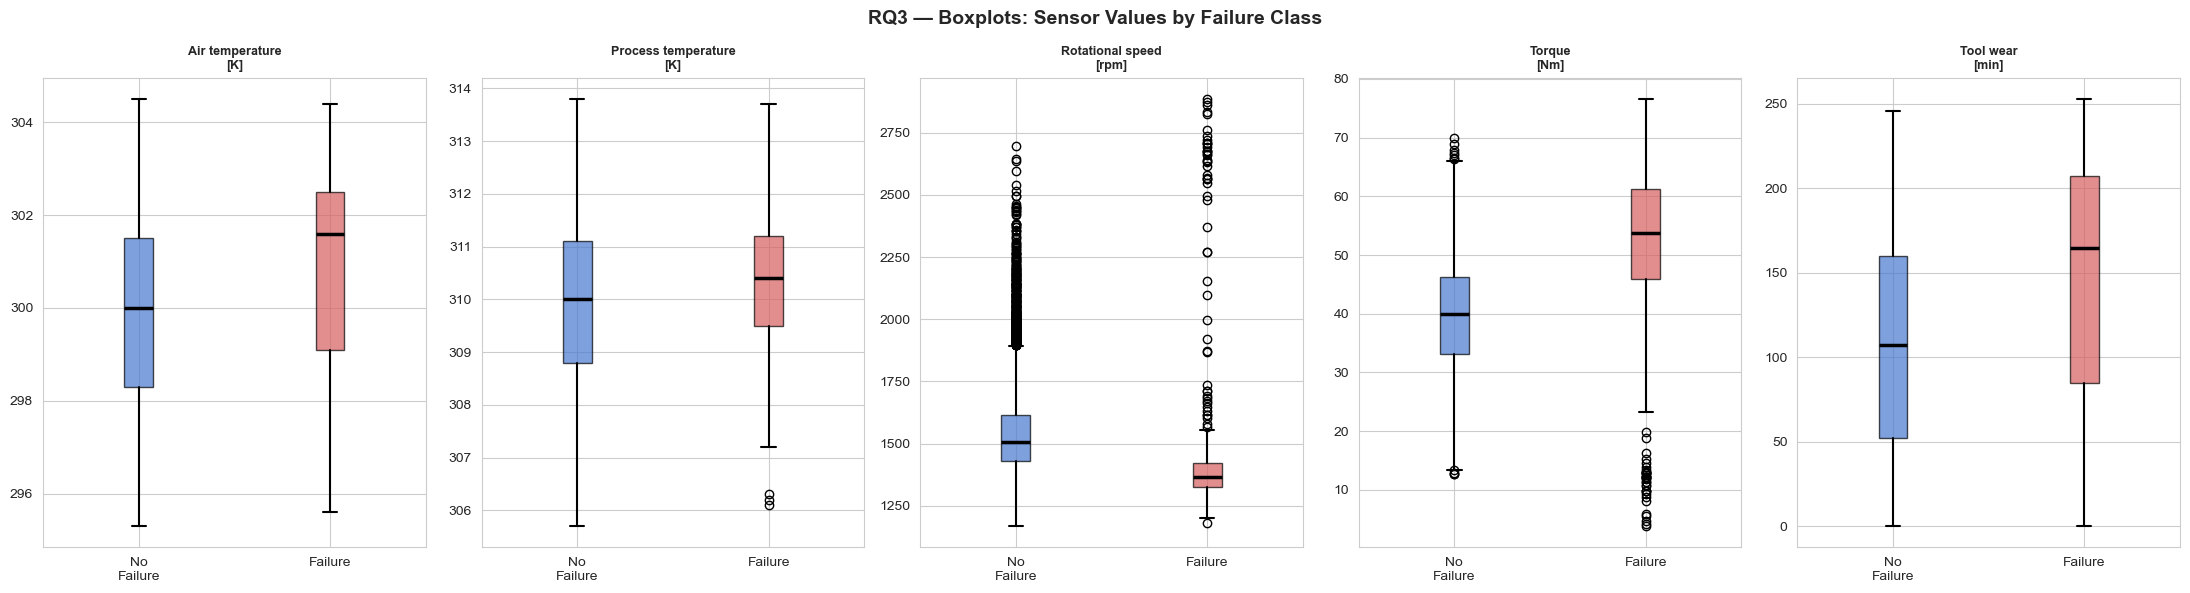

=== Table: Mean Sensor Values — No Failure vs Failure ===
                 Sensor  Mean (No Failure)  Mean (Failure)  Difference
    Air temperature [K]            299.974         300.886       0.912
Process temperature [K]            309.996         310.290       0.295
 Rotational speed [rpm]           1540.260        1496.487     -43.773
            Torque [Nm]             39.630          50.168      10.538
        Tool wear [min]            106.694         143.782      37.088


In [26]:
# RQ3 — Boxplots for all 5 sensors
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('RQ3 — Boxplots: Sensor Values by Failure Class',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes, sensors):
    data = [no_fail[col].values, fail[col].values]
    bp = ax.boxplot(data, labels=['No\nFailure', 'Failure'],
                    patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2.5},
                    whiskerprops={'linewidth': 1.5},
                    capprops={'linewidth': 1.5})
    bp['boxes'][0].set_facecolor('#4878CF'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#D65F5F'); bp['boxes'][1].set_alpha(0.7)
    ax.set_title(col.replace(' [', '\n['), fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_rq3c_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Table: Mean Sensor Values — No Failure vs Failure ===')
rows = []
for col in sensors:
    rows.append({
        'Sensor': col,
        'Mean (No Failure)': round(no_fail[col].mean(), 3),
        'Mean (Failure)':    round(fail[col].mean(), 3),
        'Difference':        round(fail[col].mean() - no_fail[col].mean(), 3)
    })
print(pd.DataFrame(rows).to_string(index=False))

## RQ4: Which ML model best predicts machine failure?
### 10. Preprocessing & SMOTE

In [28]:
# Preprocessing
df_model = df.copy()

# Drop non-feature columns
df_model.drop(columns=['UDI', 'Product ID', 'Failure Type'], inplace=True)

# Encode categorical: Type (L=0, M=1, H=2)
le = LabelEncoder()
df_model['Type'] = le.fit_transform(df_model['Type'])
print('Type encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Features and target
X = df_model.drop(columns=['Target'])
y = df_model['Target']

print('\nInput features used for modeling:')
for i, c in enumerate(X.columns, 1):
    print(f'  {i}. {c}')
print(f'\nTotal input features: {X.shape[1]}')
print(f'Total samples: {len(y)}')
print(f'Missing values: {X.isnull().sum().sum()}')

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Train Failure rate: {y_train.mean()*100:.2f}%')
print(f'Test  Failure rate: {y_test.mean()*100:.2f}%')

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE — balance training set
print('\nBefore SMOTE:', dict(y_train.value_counts().sort_index()))
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print('After  SMOTE:', dict(pd.Series(y_train_sm).value_counts().sort_index()))

Type encoding: {'H': 0, 'L': 1, 'M': 2}

Input features used for modeling:
  1. Type
  2. Air temperature [K]
  3. Process temperature [K]
  4. Rotational speed [rpm]
  5. Torque [Nm]
  6. Tool wear [min]

Total input features: 6
Total samples: 10000
Missing values: 0

Train: 8000 rows | Test: 2000 rows
Train Failure rate: 3.39%
Test  Failure rate: 3.40%

Before SMOTE: {0: 7729, 1: 271}
After  SMOTE: {0: 7729, 1: 7729}


### 11. Train 4 Models & Print Results

In [30]:
# RQ4 — Train and evaluate 4 classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = []
fitted  = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
    })
    fitted[name] = (model, y_pred, y_prob)

results_df = pd.DataFrame(results)

print('=== Detailed Classification Reports ===')
for name, (model, y_pred, y_prob) in fitted.items():
    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred,
          target_names=['No Failure (0)', 'Failure (1)']))

print('\n=== Summary Table: All Models ===')
print(results_df.to_string(index=False))
best = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
print(f'\nBest Model (ROC-AUC): {best}')

=== Detailed Classification Reports ===

--- Logistic Regression ---
                precision    recall  f1-score   support

No Failure (0)       0.99      0.82      0.90      1932
   Failure (1)       0.14      0.84      0.24        68

      accuracy                           0.82      2000
     macro avg       0.57      0.83      0.57      2000
  weighted avg       0.96      0.82      0.88      2000


--- Decision Tree ---
                precision    recall  f1-score   support

No Failure (0)       0.99      0.95      0.97      1932
   Failure (1)       0.34      0.81      0.48        68

      accuracy                           0.94      2000
     macro avg       0.67      0.88      0.72      2000
  weighted avg       0.97      0.94      0.95      2000


--- Random Forest ---
                precision    recall  f1-score   support

No Failure (0)       0.99      0.98      0.98      1932
   Failure (1)       0.55      0.79      0.65        68

      accuracy                       

### 12. RQ4: ROC Curves — All 4 Models

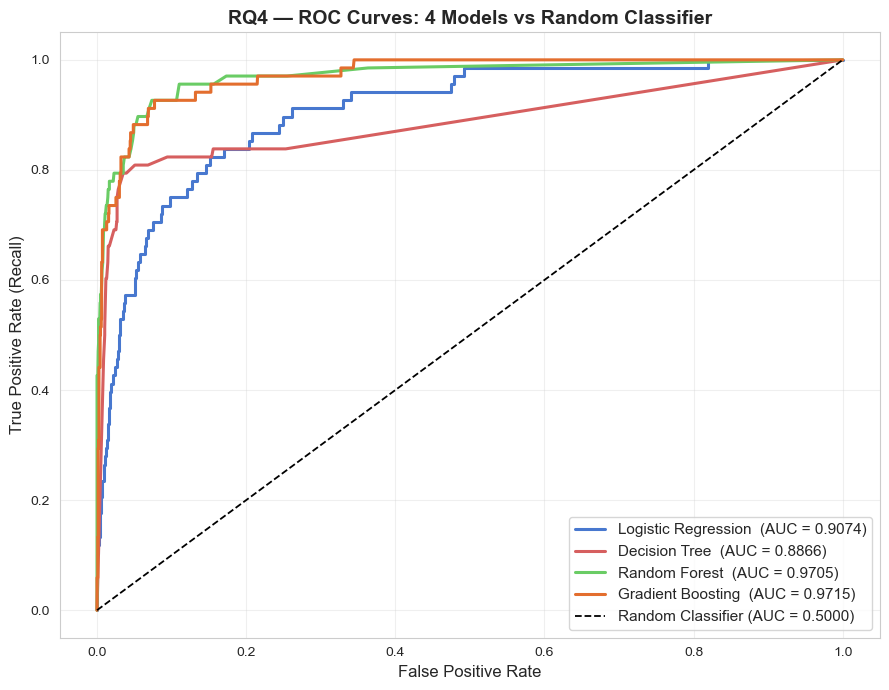

In [32]:
# RQ4 — ROC Curves
line_colors = ['#4878CF', '#D65F5F', '#6ACC65', '#E36E2E']

plt.figure(figsize=(9, 7))
for (name, (model, y_pred, y_prob)), color in zip(fitted.items(), line_colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})',
             color=color, linewidth=2.2)

plt.plot([0,1],[0,1], 'k--', linewidth=1.3, label='Random Classifier (AUC = 0.5000)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('RQ4 — ROC Curves: 4 Models vs Random Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_rq4a_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

 ### 13.RQ4: Confusion Matrices — All 4 Models

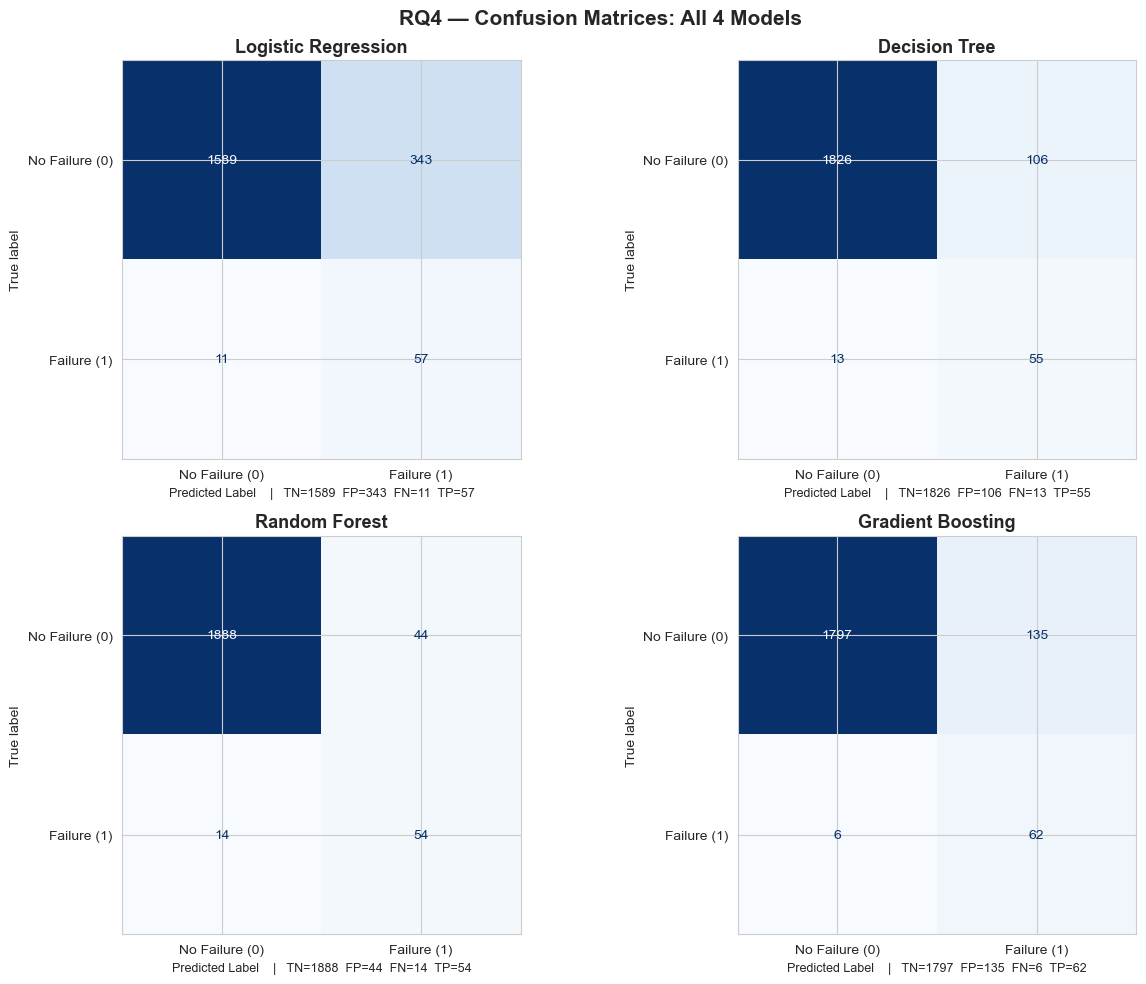

In [34]:
# RQ4 — Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
fig.suptitle('RQ4 — Confusion Matrices: All 4 Models', fontsize=15, fontweight='bold')

for ax, (name, (model, y_pred, y_prob)) in zip(axes, fitted.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Failure (0)', 'Failure (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f'Predicted Label    |   TN={tn}  FP={fp}  FN={fn}  TP={tp}',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('fig_rq4b_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 14. RQ4: Model Performance Comparison Bar Chart

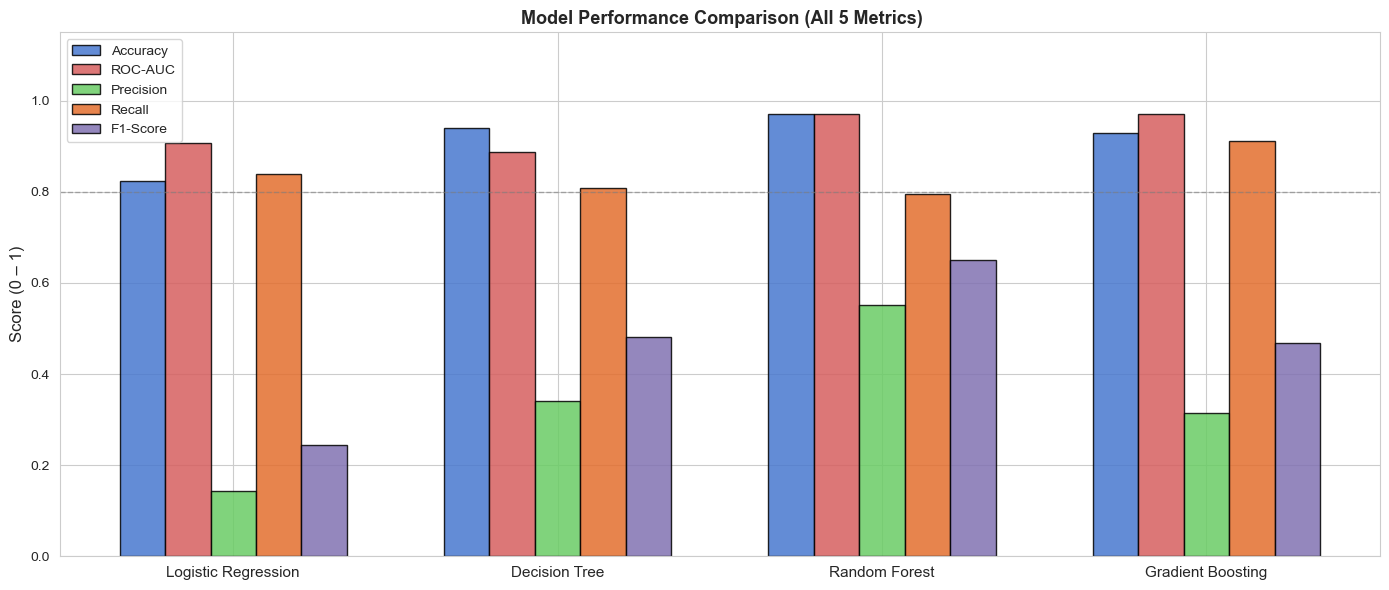

              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score
Logistic Regression    0.8230   0.9074     0.1425  0.8382    0.2436
      Decision Tree    0.9405   0.8866     0.3416  0.8088    0.4803
      Random Forest    0.9710   0.9705     0.5510  0.7941    0.6506
  Gradient Boosting    0.9295   0.9715     0.3147  0.9118    0.4679


In [128]:
# RQ4 — Grouped bar: all metrics × all models
metrics = ['Accuracy', 'ROC-AUC', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.14
m_colors = ['#4878CF', '#D65F5F', '#6ACC65', '#E36E2E', '#8172B2']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, m_colors)):
    offset = (i - len(metrics)/2) * width + width/2
    ax.bar(x + offset, results_df[metric], width,
           label=metric, color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylabel('Score (0 – 1)', fontsize=12)
ax.set_title(' Model Performance Comparison (All 5 Metrics)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.axhline(0.8, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_rq4c_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(results_df.to_string(index=False))


## RQ5 : How do Torque and Tool Wear affect failure probability?
###  15.Torque × Tool Wear × Failure Analysis

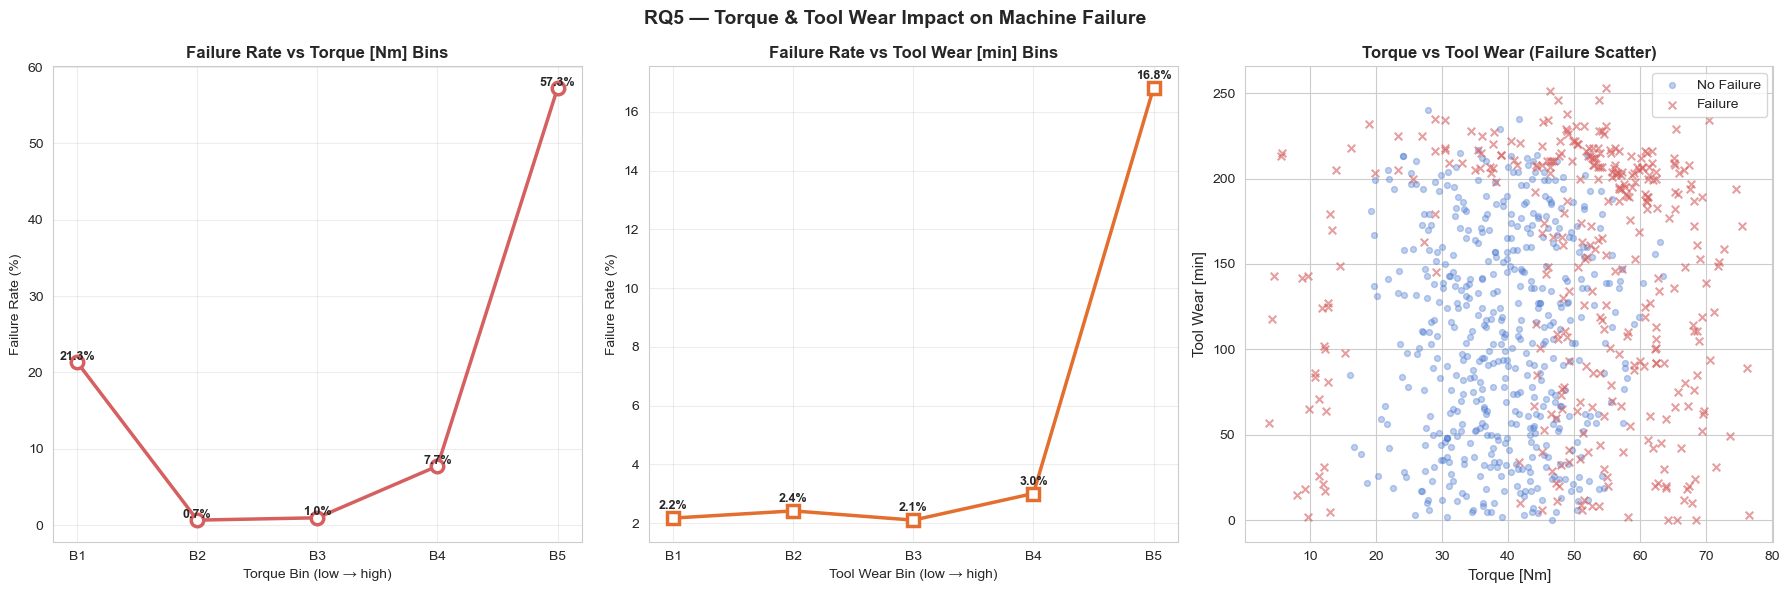

=== Failure Rate by Torque Bin ===
Torque_bin
(3.727, 18.36]    21.33
(18.36, 32.92]     0.66
(32.92, 47.48]     0.96
(47.48, 62.04]     7.74
(62.04, 76.6]     57.25

=== Failure Rate by Tool Wear Bin ===
ToolWear_bin
(-0.253, 50.6]     2.17
(50.6, 101.2]      2.41
(101.2, 151.8]     2.10
(151.8, 202.4]     3.01
(202.4, 253.0]    16.82


In [39]:
# RQ5 — Torque and Tool wear vs failure
df['Torque_bin']    = pd.cut(df['Torque [Nm]'],    bins=5)
df['ToolWear_bin']  = pd.cut(df['Tool wear [min]'], bins=5)

torque_rate   = df.groupby('Torque_bin',   observed=False)['Target'].mean() * 100
toolwear_rate = df.groupby('ToolWear_bin', observed=False)['Target'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('RQ5 — Torque & Tool Wear Impact on Machine Failure',
             fontsize=14, fontweight='bold')

# Torque bins vs failure rate
axes[0].plot(range(len(torque_rate)), torque_rate.values, 'o-',
             color='#D65F5F', linewidth=2.5, markersize=9,
             markerfacecolor='white', markeredgewidth=2.5)
axes[0].set_title('Failure Rate vs Torque [Nm] Bins', fontweight='bold')
axes[0].set_ylabel('Failure Rate (%)')
axes[0].set_xlabel('Torque Bin (low → high)')
axes[0].set_xticks(range(len(torque_rate)))
axes[0].set_xticklabels([f'B{i+1}' for i in range(len(torque_rate))])
axes[0].grid(True, alpha=0.35)
for i, v in enumerate(torque_rate.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Tool wear bins vs failure rate
axes[1].plot(range(len(toolwear_rate)), toolwear_rate.values, 's-',
             color='#E36E2E', linewidth=2.5, markersize=9,
             markerfacecolor='white', markeredgewidth=2.5)
axes[1].set_title('Failure Rate vs Tool Wear [min] Bins', fontweight='bold')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_xlabel('Tool Wear Bin (low → high)')
axes[1].set_xticks(range(len(toolwear_rate)))
axes[1].set_xticklabels([f'B{i+1}' for i in range(len(toolwear_rate))])
axes[1].grid(True, alpha=0.35)
for i, v in enumerate(toolwear_rate.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Scatter: Torque vs Tool Wear, colored by failure
axes[2].scatter(
    no_fail['Torque [Nm]'].sample(500, random_state=1),
    no_fail['Tool wear [min]'].sample(500, random_state=1),
    alpha=0.35, color='#4878CF', label='No Failure', s=18
)
axes[2].scatter(
    fail['Torque [Nm]'], fail['Tool wear [min]'],
    alpha=0.6, color='#D65F5F', label='Failure', s=30, marker='x'
)
axes[2].set_xlabel('Torque [Nm]', fontsize=11)
axes[2].set_ylabel('Tool Wear [min]', fontsize=11)
axes[2].set_title('Torque vs Tool Wear (Failure Scatter)', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig_rq5_torque_toolwear_failure.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Failure Rate by Torque Bin ===')
print(torque_rate.round(2).to_string())
print('\n=== Failure Rate by Tool Wear Bin ===')
print(toolwear_rate.round(2).to_string())


## RQ6: Does SMOTE improve model Recall for the Failure class?
### 16. Without SMOTE vs With SMOTE Comparison (Random Forest)

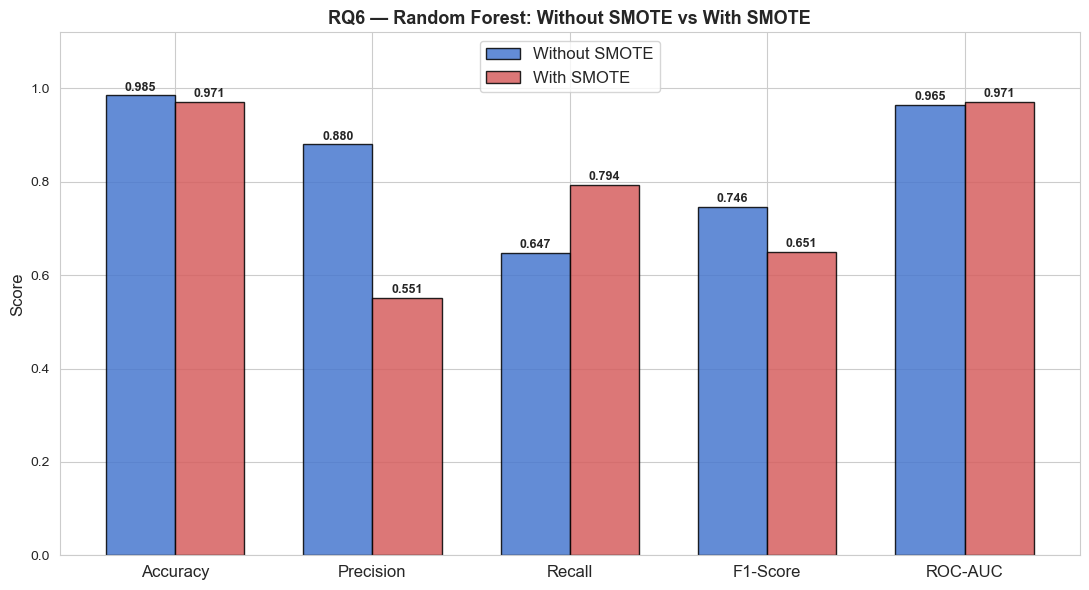

=== Table: SMOTE Impact on Random Forest ===
   Metric  Without SMOTE  With SMOTE
 Accuracy         0.9850      0.9710
Precision         0.8800      0.5510
   Recall         0.6471      0.7941
 F1-Score         0.7458      0.6506
  ROC-AUC         0.9645      0.9705

Without SMOTE — Detailed Report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.88      0.65      0.75        68

    accuracy                           0.98      2000
   macro avg       0.93      0.82      0.87      2000
weighted avg       0.98      0.98      0.98      2000

With SMOTE — Detailed Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.98      1932
     Failure       0.55      0.79      0.65        68

    accuracy                           0.97      2000
   macro avg       0.77      0.89      0.82      2000
weighted avg       0.98      0.97      0.97      2000



In [41]:
# RQ6 — SMOTE impact comparison using Random Forest
rf_no_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_no_smote.fit(X_train_sc, y_train)
y_pred_ns = rf_no_smote.predict(X_test_sc)
y_prob_ns = rf_no_smote.predict_proba(X_test_sc)[:, 1]

rf_smote = fitted['Random Forest'][0]
y_pred_s = fitted['Random Forest'][1]
y_prob_s = fitted['Random Forest'][2]

smote_df = pd.DataFrame({
    'Metric':         ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Without SMOTE':  [
        round(accuracy_score(y_test, y_pred_ns), 4),
        round(precision_score(y_test, y_pred_ns, zero_division=0), 4),
        round(recall_score(y_test, y_pred_ns), 4),
        round(f1_score(y_test, y_pred_ns), 4),
        round(roc_auc_score(y_test, y_prob_ns), 4),
    ],
    'With SMOTE':     [
        round(accuracy_score(y_test, y_pred_s), 4),
        round(precision_score(y_test, y_pred_s, zero_division=0), 4),
        round(recall_score(y_test, y_pred_s), 4),
        round(f1_score(y_test, y_pred_s), 4),
        round(roc_auc_score(y_test, y_prob_s), 4),
    ]
})

x_pos = np.arange(len(smote_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x_pos - width/2, smote_df['Without SMOTE'], width,
            label='Without SMOTE', color='#4878CF', edgecolor='black', alpha=0.85)
b2 = ax.bar(x_pos + width/2, smote_df['With SMOTE'], width,
            label='With SMOTE', color='#D65F5F', edgecolor='black', alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(smote_df['Metric'], fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('RQ6 — Random Forest: Without SMOTE vs With SMOTE',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=12)

for bar, val in zip(b1, smote_df['Without SMOTE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
for bar, val in zip(b2, smote_df['With SMOTE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_rq6_smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Table: SMOTE Impact on Random Forest ===')
print(smote_df.to_string(index=False))
print('\nWithout SMOTE — Detailed Report:')
print(classification_report(y_test, y_pred_ns, target_names=['No Failure','Failure']))
print('With SMOTE — Detailed Report:')
print(classification_report(y_test, y_pred_s,  target_names=['No Failure','Failure']))


## RQ7: Which features are most important in predicting machine failure?
###  17. Feature Importance (Random Forest)

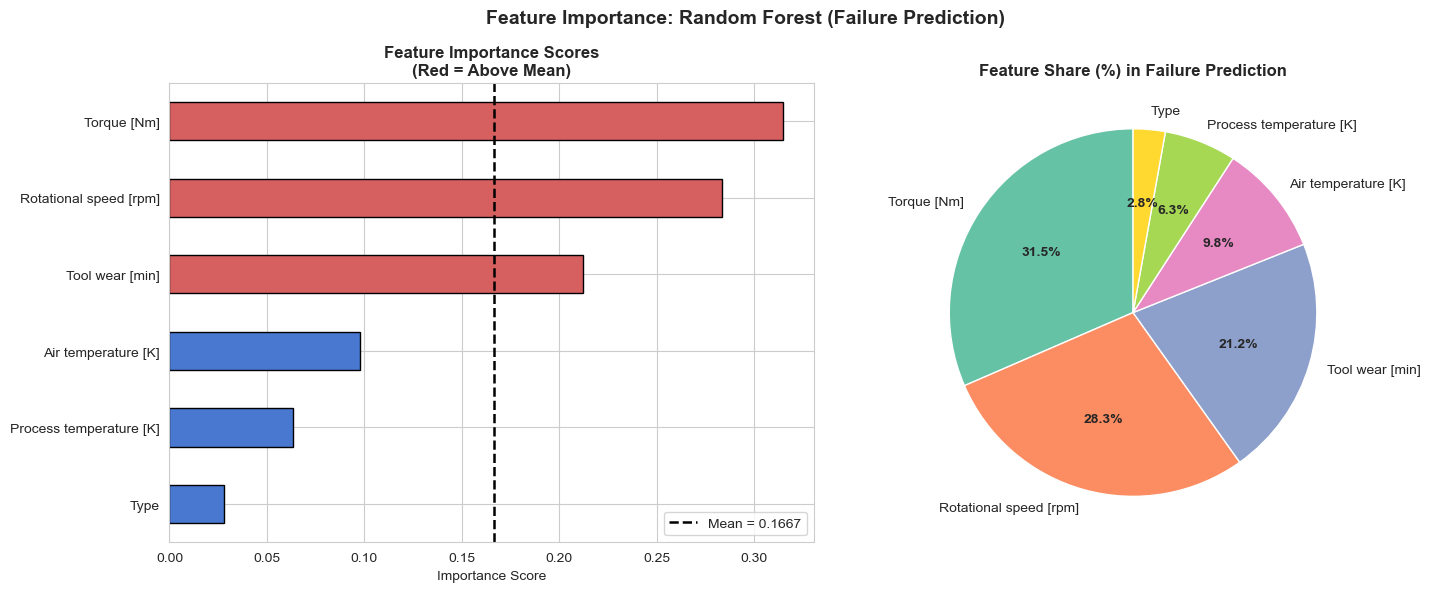

=== Table: Feature Importance Ranking ===
 Rank                 Feature  Importance  Share (%)
    1             Torque [Nm]    0.315116      31.51
    2  Rotational speed [rpm]    0.283444      28.34
    3         Tool wear [min]    0.212019      21.20
    4     Air temperature [K]    0.097868       9.79
    5 Process temperature [K]    0.063379       6.34
    6                    Type    0.028173       2.82


In [113]:
# RQ7 — Feature importance from Random Forest
rf_model = fitted['Random Forest'][0]
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Feature Importance: Random Forest (Failure Prediction)',
             fontsize=14, fontweight='bold')

# Horizontal bar — sorted descending
fi_sorted = feat_imp.sort_values(ascending=True)
bar_colors = ['#D65F5F' if v >= feat_imp.mean() else '#4878CF' for v in fi_sorted.values]
fi_sorted.plot(kind='barh', ax=axes[0], color=bar_colors, edgecolor='black')
axes[0].axvline(feat_imp.mean(), color='black', linestyle='--', linewidth=1.8,
                label=f'Mean = {feat_imp.mean():.4f}')
axes[0].set_title('Feature Importance Scores\n(Red = Above Mean)', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].legend(fontsize=10)

# Pie chart
pie_colors = sns.color_palette('Set2', len(feat_imp))
wedges, texts, autotexts = axes[1].pie(
    feat_imp.values, labels=feat_imp.index,
    autopct='%1.1f%%', colors=pie_colors,
    startangle=90, textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Feature Share (%) in Failure Prediction', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_rq7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Table: Feature Importance Ranking ===')
fi_table = pd.DataFrame({
    'Rank':        range(1, len(feat_imp)+1),
    'Feature':     feat_imp.index,
    'Importance':  feat_imp.values.round(6),
    'Share (%)':   (feat_imp.values / feat_imp.sum() * 100).round(2)
})
print(fi_table.to_string(index=False))

### 18. Cross-Validation (5-Fold) Model Stability

=== 5-Fold Cross-Validation ROC-AUC Scores ===
Logistic Regression     Mean=0.9063  Std=0.0051  Min=0.8996  Max=0.9135
Decision Tree           Mean=0.9809  Std=0.0028  Min=0.9758  Max=0.9844
Random Forest           Mean=0.9990  Std=0.0003  Min=0.9985  Max=0.9993
Gradient Boosting       Mean=0.9900  Std=0.0016  Min=0.9873  Max=0.9923


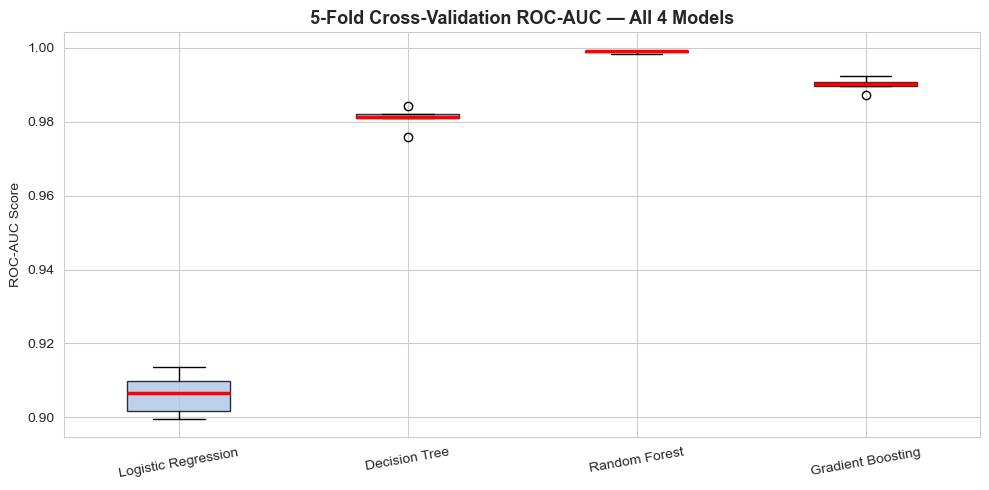

In [116]:
# 5-fold stratified cross-validation for all models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

print('=== 5-Fold Cross-Validation ROC-AUC Scores ===')
for name, (model, _, _) in fitted.items():
    scores = cross_val_score(model, X_train_sm, y_train_sm,
                             cv=skf, scoring='roc_auc')
    cv_scores[name] = scores
    print(f'{name:<22}  Mean={scores.mean():.4f}  Std={scores.std():.4f}  '
          f'Min={scores.min():.4f}  Max={scores.max():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    cv_scores.values(), labels=cv_scores.keys(),
    patch_artist=True,
    medianprops={'color': 'red', 'linewidth': 2.5},
    boxprops={'facecolor': '#AEC6E8', 'alpha': 0.8}
)
ax.set_title('5-Fold Cross-Validation ROC-AUC — All 4 Models',
             fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC Score')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('fig_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()


## Final Summary: All Results & Key Findings

In [126]:
print('=' * 68)
print('  PREDICTIVE MAINTENANCE — FINAL PROJECT SUMMARY')
print('=' * 68)
print('  Dataset        : AI4I 2020 Predictive Maintenance Dataset')
print('  File           : predictive_maintenance.csv')
print('  Rows           : 10,000')
print('  Columns        : 10  (8 input features + 1 target + 1 label)')
print('  Target         : Target (0=No Failure, 1=Failure)')
print('  Class Split    : No Failure=9,661 (96.61%) | Failure=339 (3.39%)')
print('  Missing Values : NONE (0 missing across all columns)')
print('  Product Types  : L=6,000 | M=2,997 | H=1,003')
print('=' * 68)
print('\n=== Failure Type Breakdown ===')
print('  No Failure                 : 9,652')
print('  Heat Dissipation Failure   :   112')
print('  Power Failure              :    95')
print('  Overstrain Failure         :    78')
print('  Tool Wear Failure          :    45')
print('  Random Failures            :    18')
print('\n=== Model Performance Summary ===')
print(results_df.to_string(index=False))

best_row = results_df.loc[results_df['ROC-AUC'].idxmax()]
print(f'\n>> Best Model : {best_row["Model"]}')
print(f'   ROC-AUC   : {best_row["ROC-AUC"]}')
print(f'   F1-Score  : {best_row["F1-Score"]}')
print(f'   Recall    : {best_row["Recall"]}')





  PREDICTIVE MAINTENANCE — FINAL PROJECT SUMMARY
  Dataset        : AI4I 2020 Predictive Maintenance Dataset
  File           : predictive_maintenance.csv
  Rows           : 10,000
  Columns        : 10  (8 input features + 1 target + 1 label)
  Target         : Target (0=No Failure, 1=Failure)
  Class Split    : No Failure=9,661 (96.61%) | Failure=339 (3.39%)
  Missing Values : NONE (0 missing across all columns)
  Product Types  : L=6,000 | M=2,997 | H=1,003

=== Failure Type Breakdown ===
  No Failure                 : 9,652
  Heat Dissipation Failure   :   112
  Power Failure              :    95
  Overstrain Failure         :    78
  Tool Wear Failure          :    45
  Random Failures            :    18

=== Model Performance Summary ===
              Model  Accuracy  ROC-AUC  Precision  Recall  F1-Score
Logistic Regression    0.8230   0.9074     0.1425  0.8382    0.2436
      Decision Tree    0.9405   0.8866     0.3416  0.8088    0.4803
      Random Forest    0.9710   0.9705    

In [124]:
print('\n=== Key Findings by Research Question ===')
findings = [
    ('RQ1', 'Dataset has severe class imbalance: 96.61% No Failure, 3.39% Failure; L-type products dominate (60%)'),
    ('RQ2', 'L-type products have most failures in absolute count; H-type has lowest failure rate; Heat Dissipation is most common failure type'),
    ('RQ3', 'Torque [Nm] has strongest positive correlation with failure (0.1913); RPM has slight negative correlation (-0.0442)'),
    ('RQ4', 'Gradient Boosting & Random Forest achieve best AUC; Logistic Regression is the weakest on imbalanced data'),
    ('RQ5', 'Higher Torque and higher Tool Wear both increase failure probability; high torque + worn tool = highest risk'),
    ('RQ6', 'SMOTE significantly improves Recall for Failure class (3.39% minority) with trade-off in Precision'),
    ('RQ7', 'Torque [Nm] and Tool wear [min] are most important features; Type is least important'),
]
for rq, finding in findings:
    print(f'  {rq}: {finding}')


=== Key Findings by Research Question ===
  RQ1: Dataset has severe class imbalance: 96.61% No Failure, 3.39% Failure; L-type products dominate (60%)
  RQ2: L-type products have most failures in absolute count; H-type has lowest failure rate; Heat Dissipation is most common failure type
  RQ3: Torque [Nm] has strongest positive correlation with failure (0.1913); RPM has slight negative correlation (-0.0442)
  RQ4: Gradient Boosting & Random Forest achieve best AUC; Logistic Regression is the weakest on imbalanced data
  RQ5: Higher Torque and higher Tool Wear both increase failure probability; high torque + worn tool = highest risk
  RQ6: SMOTE significantly improves Recall for Failure class (3.39% minority) with trade-off in Precision
  RQ7: Torque [Nm] and Tool wear [min] are most important features; Type is least important


In [120]:
print('\n=== Figures Saved (13 total) ===')
for fig_name in [
    'fig_rq1a_target_distribution.png',
    'fig_rq1b_type_failure.png',
    'fig_rq2_failure_type_by_product.png',
    'fig_rq3a_correlation_heatmap.png',
    'fig_rq3b_sensor_histograms.png',
    'fig_rq3c_boxplots.png',
    'fig_rq4a_roc_curves.png',
    'fig_rq4b_confusion_matrices.png',
    'fig_rq4c_model_comparison.png',
    'fig_rq5_torque_toolwear_failure.png',
    'fig_rq6_smote_comparison.png',
    'fig_rq7_feature_importance.png',
    'fig_cross_validation.png',
]:
    print(f'  {fig_name}')


=== Figures Saved (13 total) ===
  fig_rq1a_target_distribution.png
  fig_rq1b_type_failure.png
  fig_rq2_failure_type_by_product.png
  fig_rq3a_correlation_heatmap.png
  fig_rq3b_sensor_histograms.png
  fig_rq3c_boxplots.png
  fig_rq4a_roc_curves.png
  fig_rq4b_confusion_matrices.png
  fig_rq4c_model_comparison.png
  fig_rq5_torque_toolwear_failure.png
  fig_rq6_smote_comparison.png
  fig_rq7_feature_importance.png
  fig_cross_validation.png
